# Tabular competition starter notebook
Written by:

Copy (fork) and edit as many copies of this notebook as you require 

In [108]:
competition = "u-tad-26-ml-1-regression-gemstone-prices"
target = "price"

In [109]:
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 36)
pd.set_option("display.max_colwidth", 72)

seed = 42
import numpy as np
np.random.seed(seed)

# graphics
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 20})
plt.rcParams["figure.figsize"] = (11, 6.8)
#plt.style.use('fivethirtyeight')

import seaborn as sns
sns.set(font_scale=1)
#sns.set_style("whitegrid")

import plotly.io as pio
# for use in JupyterLab 4
pio.renderers.default = 'iframe'
# for use in Google Colab
#pio.renderers.default = 'colab'
import plotly as py
import plotly.express as px

## Read in the training data

In [110]:
dataset = pd.read_csv( f"/kaggle/input/competitions/{competition}/dataset.csv" )
dataset

,id,carat,Arkenfactor,cut,color,clarity,depth,table,x,y,z,price
0,0,NaN,920.482144,Premium,NaN,IF,62.4,61.0,6.38,6.41,3.99,8501
1,1,NaN,554.053739,Ideal,F,VS2,61.2,56.0,7.38,7.44,4.54,14777
2,2,1.14,909.893590,Very Good,H,SI2,61.7,62.0,6.62,6.69,4.11,4842
3,3,0.41,1142.137110,Premium,G,VS2,59.9,57.0,4.81,4.84,2.89,1061
4,4,1.06,727.724583,Ideal,E,SI2,61.8,55.0,6.53,6.55,4.04,4511
...,...,...,...,...,...,...,...,...,...,...,...,...
1245,1245,NaN,713.346269,Premium,G,VS2,61.7,57.0,6.57,6.62,4.07,6230
1246,1246,0.52,665.188653,Ideal,E,VVS1,61.8,56.0,5.18,5.22,3.22,2685
1247,1247,0.30,1249.000000,Ideal,G,VVS2,62.5,57.0,4.32,4.30,2.70,878
1248,1248,0.35,795.463563,Premium,F,SI1,62.8,58.0,4.54,4.50,2.84,706


In [111]:
df = dataset
df.describe()

,id,carat,Arkenfactor,depth,table,x,y,z,price
count,1250.000000,1006.000000,1250.000000,1250.00000,1250.000000,1250.000000,1250.000000,1250.000000,1250.000000
mean,624.500000,0.795716,636.270720,61.80544,57.267600,5.715872,5.720728,3.534176,4043.516000
std,360.988227,0.476258,392.427468,1.09012,1.882318,1.125061,1.120034,0.695977,4157.971825
min,0.000000,0.200000,0.000000,56.50000,53.000000,3.820000,3.780000,2.320000,338.000000
25%,312.250000,0.380000,311.904694,61.30000,56.000000,4.670000,4.682500,2.880000,946.000000
50%,624.500000,0.700000,636.000237,61.90000,57.000000,5.690000,5.715000,3.520000,2365.000000
75%,936.750000,1.040000,944.658186,62.40000,58.000000,6.530000,6.530000,4.030000,5480.250000
max,1249.000000,2.620000,1249.000000,67.90000,67.000000,8.930000,8.860000,5.640000,18736.000000


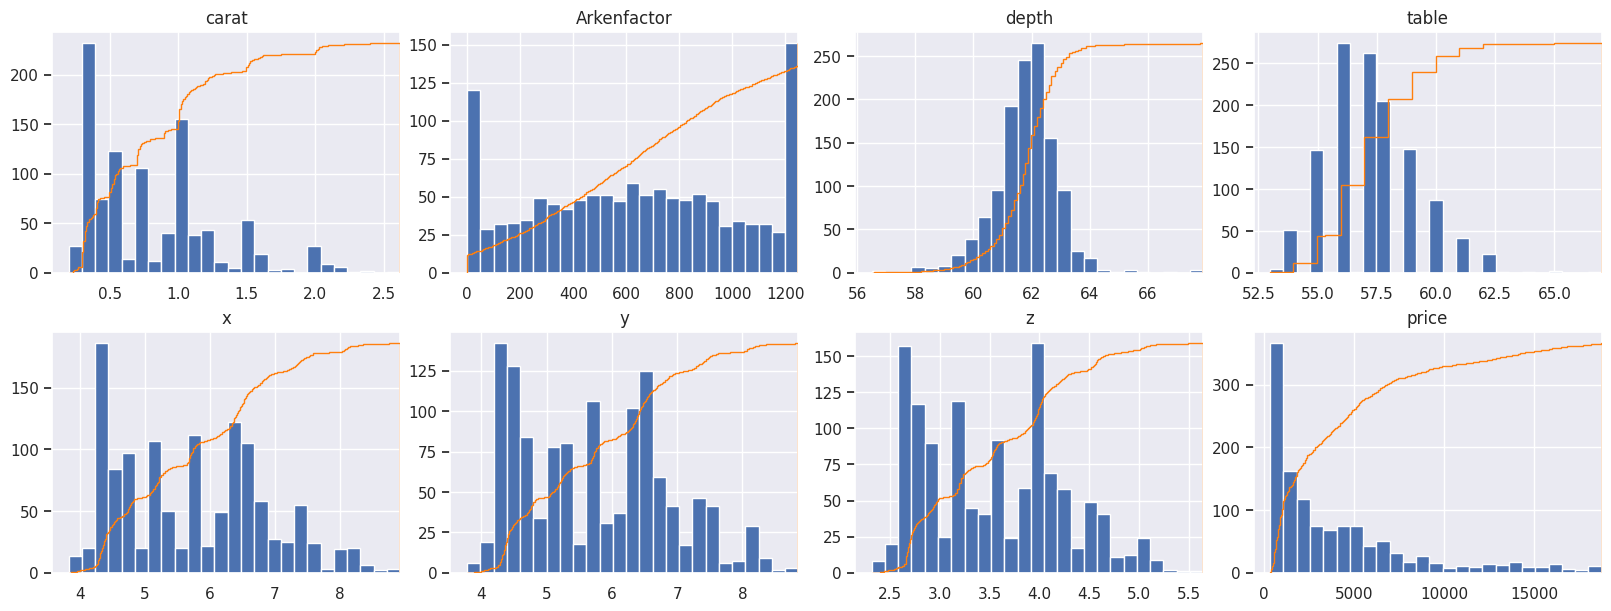

In [112]:
numeric_cols = ["carat", "Arkenfactor", "depth", "table", "x", "y", "z", "price"]

ncols = 4
nrows = -(-len(numeric_cols) // ncols)   # ceil division

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(4 * ncols, 3 * nrows),
                         constrained_layout=True)

for ax, col in zip(axes.flat, numeric_cols):
    series = df[col]
    ax2 = ax.twinx()
    ax.hist(series, bins=25)
    ax2.hist(series, cumulative=1, histtype="step", bins=500, color="tab:orange")
    ax2.axis("off")
    ax.set_xlim(ax.get_xlim()[0], series.max())
    ax.set_title(col)

# only matters if len(numeric_cols) isn't a multiple of ncols
for ax in axes.flat[len(numeric_cols):]:
    ax.remove()

fig.savefig("numeric_distributions.png", dpi=200)

<Axes: xlabel='cut', ylabel='count'>

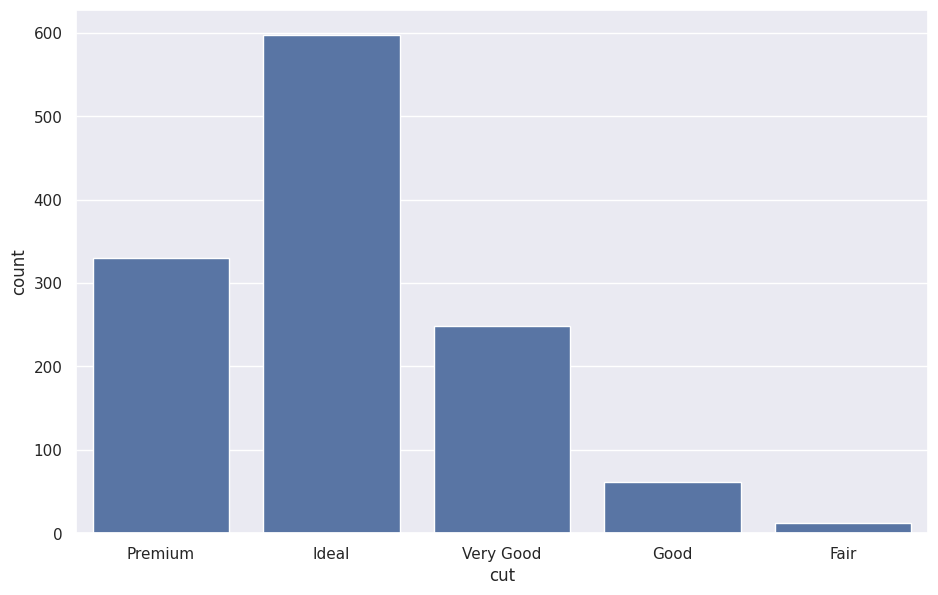

In [113]:
sns.countplot(df, x="cut")

<Axes: xlabel='cut', ylabel='count'>

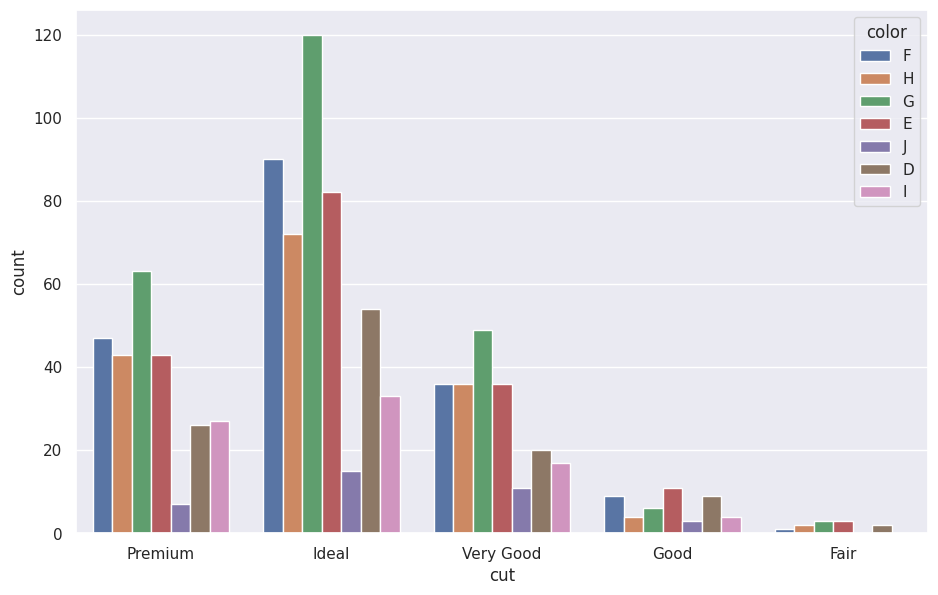

In [114]:
sns.countplot(df, x="cut", hue="color")

In [115]:
df_cut = df.groupby(by="cut")["price"]
df_cut.describe()

,count,mean,std,min,25%,50%,75%,max
cut,,,,,,,,
Fair,12.0,3504.583333,3453.726748,716.0,1998.00,2373.0,3597.75,13784.0
Good,61.0,5005.786885,4316.846573,373.0,2312.00,3697.0,6006.00,18242.0
Ideal,598.0,3431.979933,3877.918414,345.0,878.00,1716.0,4830.00,18736.0
Premium,330.0,4942.300000,4548.583552,367.0,1128.75,3815.0,6432.50,18709.0
Very Good,249.0,4111.261044,4020.239378,338.0,789.00,2885.0,5543.00,18557.0


In [116]:
cut_dic = {
    "Premium": 5,
    "Ideal": 4,
    "Very Good Cut": 3,
    "Good": 2,
    "Fair": 1
}

## 1. EDA
Perform an EDA of the dataset.

## 2. Data cleaning

Check that the dataset is now ready for machine learning:

In [117]:
# assert dataset.shape[1] == dataset.select_dtypes(include='number').shape[1], "FAIL: There are categorical columns that need numerical encoding."
# assert dataset.isna().sum().sum() == 0, "FAIL: There are missing values."

## 3. Calculate the "baseline model" score
Split the data into disjoint training and local validation datasets using [`train_test_split`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html), then calculate the local performance of the "average" model

In [118]:
# 1. Split data
X = df
y = X.pop("price")

from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [124]:
y_base = np.full(len(y_val), np.mean(y_train[:250]))
y_base

array([4385.764, 4385.764, 4385.764, 4385.764, 4385.764, 4385.764,
       4385.764, 4385.764, 4385.764, 4385.764, 4385.764, 4385.764,
       4385.764, 4385.764, 4385.764, 4385.764, 4385.764, 4385.764,
       4385.764, 4385.764, 4385.764, 4385.764, 4385.764, 4385.764,
       4385.764, 4385.764, 4385.764, 4385.764, 4385.764, 4385.764,
       4385.764, 4385.764, 4385.764, 4385.764, 4385.764, 4385.764,
       4385.764, 4385.764, 4385.764, 4385.764, 4385.764, 4385.764,
       4385.764, 4385.764, 4385.764, 4385.764, 4385.764, 4385.764,
       4385.764, 4385.764, 4385.764, 4385.764, 4385.764, 4385.764,
       4385.764, 4385.764, 4385.764, 4385.764, 4385.764, 4385.764,
       4385.764, 4385.764, 4385.764, 4385.764, 4385.764, 4385.764,
       4385.764, 4385.764, 4385.764, 4385.764, 4385.764, 4385.764,
       4385.764, 4385.764, 4385.764, 4385.764, 4385.764, 4385.764,
       4385.764, 4385.764, 4385.764, 4385.764, 4385.764, 4385.764,
       4385.764, 4385.764, 4385.764, 4385.764, 4385.764, 4385.

## 4. Our machine learning (ML) 

In [ ]:
from sklearn.linear_model import LinearRegression

y = y_train

## 5. Fit your model to `X_train`, `y_train`

## 6. Calculate the local validation score for the `X_validation` dataset
Calculate the local RMSE score for the ML model from the validation split

## 7. Local validation and Kaggle leaderboard: Results

| Model  | RMSE (local validation)|  RMSE (Public Leaderboard)| 
| --- |  --- | --- | 
| Baseline | ???? | ???? |
| `LinearRegression`  | ???? | ???? |
| `DecisionTreeRegressor` (max_depth=2) | ???? | ???? |
| `DecisionTreeRegressor` (max_depth=3) | ???? | ???? |
| `DecisionTreeRegressor` (max_depth=4) | ???? | ???? |
| `DecisionTreeRegressor` (max_depth=5) | ???? | ???? |
| `DecisionTreeRegressor` (max_depth=6) | ???? | ???? |
| `DecisionTreeRegressor` (max_depth=7) | ???? | ???? |
| `DecisionTreeRegressor` (max_depth=8) | ???? | ???? |
| `DecisionTreeRegressor` (max_depth=9) | ???? | ???? |
| `DecisionTreeRegressor` (max_depth=10) | ???? | ???? |
| `DecisionTreeRegressor` (max_depth=11) | ???? | ???? |
| `DecisionTreeRegressor` (max_depth=12) | ???? | ???? |

(Note: You can view your submissions history in the **Submissions section**)

# Read in the test data that you are asked to make predictions for
This is the dataset used by Kaggle to calculate your leaderboard RMSE

In [120]:
X_test = pd.read_csv(f"/kaggle/input/competitions/{competition}/test.csv")
X_test

,id,carat,Arkenfactor,cut,color,clarity,depth,table,x,y,z
0,1250,0.30,8.597073,Ideal,E,SI1,61.6,57.0,4.33,4.34,2.67
1,1251,NaN,1175.523675,Ideal,G,VVS2,61.6,55.0,4.32,4.35,2.67
2,1252,1.22,0.000000,Ideal,G,VS2,62.1,57.0,6.81,6.84,4.24
3,1253,0.35,0.000000,Ideal,E,SI1,61.5,55.0,4.54,4.57,2.80
4,1254,1.54,0.000000,Ideal,NaN,SI1,62.7,57.0,7.34,7.39,4.62
...,...,...,...,...,...,...,...,...,...,...,...
1995,3245,0.53,959.186946,Ideal,NaN,SI2,61.6,56.0,5.18,5.21,3.21
1996,3246,NaN,833.412583,Very Good,F,SI2,63.2,55.0,6.77,6.74,4.28
1997,3247,2.00,659.980332,Good,I,VS1,64.6,56.0,7.90,7.99,5.07
1998,3248,0.30,838.396944,Very Good,G,VS1,63.1,59.0,4.28,4.24,2.69


Clean `X_test` the same way you cleaned the training data

Run a `.predict` for this new dataset

In [121]:
# tmp; remember to delete this 
y_pred = np.full(len(X_test), np.mean(y_train[:250]))

# uncomment to calculate your model predictions
#y_pred = regressor.predict(X_test)

## Submit your predictions in a `submission.csv` file for scoring on the [leaderboard](https://www.kaggle.com/competitions/u-tad-proyectos-ii-2026-precios-de-gemas/leaderboard)
To submit your notebook click on **Submit to competition** and then **Submit**.

In [122]:
# Do not modify this code
submission = pd.read_csv(f"/kaggle/input/competitions/{competition}/sample_submission.csv")
submission[target] = y_pred
submission.to_csv('submission.csv',index=False)

visual check of predictions

In [123]:
submission.head()

,id,price
0,1250,4385.764
1,1251,4385.764
2,1252,4385.764
3,1253,4385.764
4,1254,4385.764
